# PRAKTIKUM FILTER

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

In [4]:
def convolution2d(image, kernel, stride, padding):
  img = cv.imread('/content/drive/MyDrive/PCVK/Images/mandrill.tiff')
  img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)
  #image sharpen
  kernel_sharpen = np.array([[0,-1,0],
                           [-1,5,-1],
                           [0,-1,-0]])
  convolution2d(img_gray, kernel_sharpen, 1, 2)

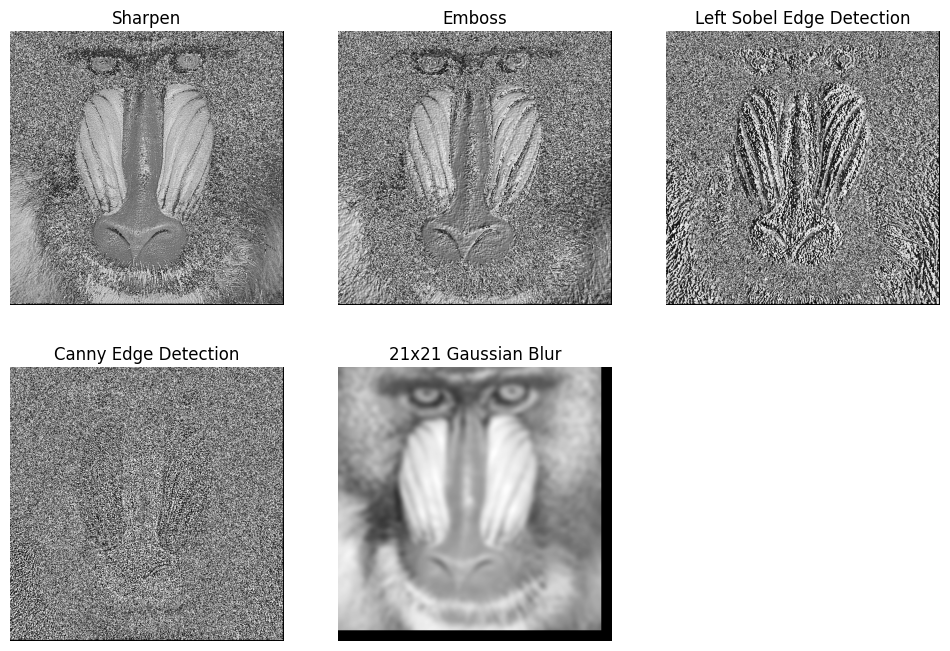

In [5]:
def convolution2d(image, kernel, stride=1, padding=0):
    kernel = np.flipud(np.fliplr(kernel))
    xKernShape, yKernShape = kernel.shape
    xImgShape, yImgShape = image.shape

    if padding > 0:
        image_padded = np.zeros((xImgShape + 2*padding, yImgShape + 2*padding))
        image_padded[padding:-padding, padding:-padding] = image
    else:
        image_padded = image

    output = np.zeros_like(image)

    for y in range(image.shape[1]):
        if y > image.shape[1] - yKernShape:
            break
        for x in range(image.shape[0]):
            if x > image.shape[0] - xKernShape:
                break
            output[x, y] = (kernel * image_padded[x: x+xKernShape, y: y+yKernShape]).sum()
    return output


img = cv.imread('/content/drive/MyDrive/PCVK/Images/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

kernel_sharpen = np.array([[0,-1,0],
                           [-1,5,-1],
                           [0,-1,0]])
kernel_emboss = np.array([[-2,-1,0],
                          [-1, 1,1],
                          [0, 1,2]])
kernel_sobel_left = np.array([[1, 0, -1],
                              [2, 0, -2],
                              [1, 0, -1]])
kernel_canny = np.array([[-1,-1,-1],
                         [-1, 8,-1],
                         [-1,-1,-1]])

kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel_1d = cv.getGaussianKernel(kernel_size, sigma)
gaussian_kernel = gaussian_kernel_1d @ gaussian_kernel_1d.T

out_sharp = convolution2d(img_gray, kernel_sharpen)
out_emboss = convolution2d(img_gray, kernel_emboss)
out_sobel = convolution2d(img_gray, kernel_sobel_left)
out_canny = convolution2d(img_gray, kernel_canny)
out_gauss = convolution2d(img_gray, gaussian_kernel)

titles = ['Sharpen','Emboss','Left Sobel Edge Detection','Canny Edge Detection','21x21 Gaussian Blur']
images = [out_sharp, out_emboss, out_sobel, out_canny, out_gauss]

plt.figure(figsize=(12,8))
for i in range(len(images)):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()


# FILTER LIBRARY DAN FILTER MODERN

## Percobaan 1:

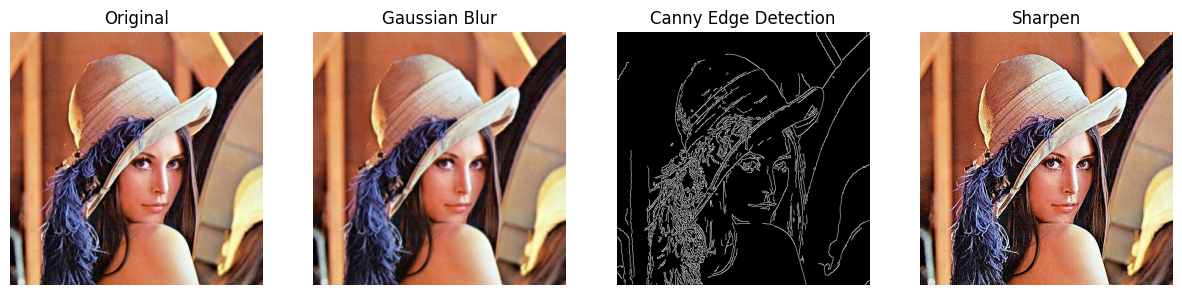

In [6]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
  plt.figure(figsize=figsize)
  for i, (img, title) in enumerate(zip(images, titles)):
      if len(img.shape) == 2: #grayscale
        plt.subplot(1, len(images), i+1)
        plt.imshow(img, cmap="gray")
      else: # color
        plt.subplot(1, len(images), i+1)
        plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
      plt.title(title)
      plt.axis("off")
  plt.show()

img=cv.imread("/content/drive/MyDrive/PCVK/Images/lena.jpg")
img_gray=cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur=cv.GaussianBlur(img, (7,7), 1)
edges=cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel=np.array([[0,-1,0], [-1,5,-1], [0,-1,0]])
sharpen=cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, edges, sharpen],
 ["Original", "Gaussian Blur", "Canny Edge Detection", "Sharpen"])

## Percobaan 2:

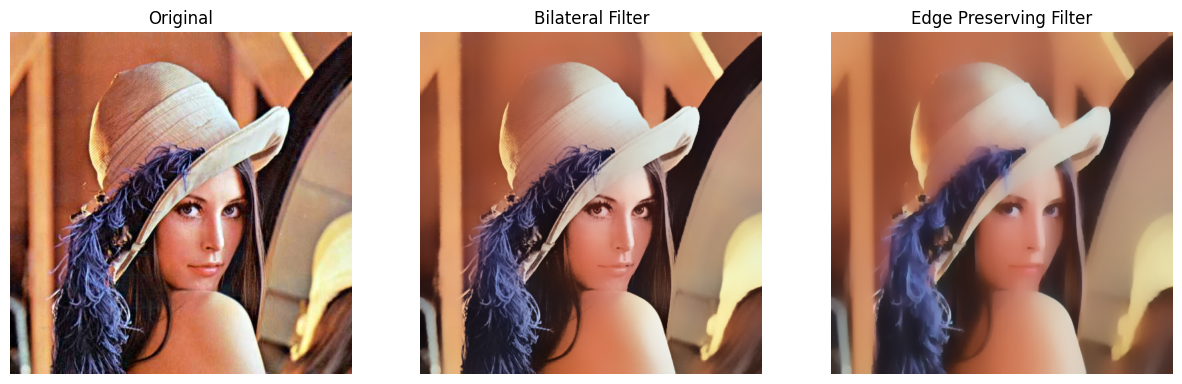

In [7]:
# filter modern dari opencv
# bilateral filter (edge-preserving)
bilateral=cv.bilateralFilter(img, 50, 100, 100)

#edge preserving filter (alternatif guided filter)
edge_preserve=cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
 ["Original", "Bilateral Filter", "Edge Preserving Filter"])

## Percobaan 3

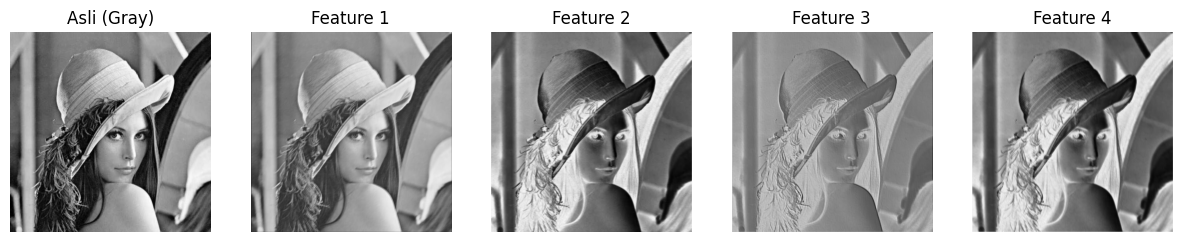

In [8]:
# Filter Feature Map yang digunakan pada CNN,

import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps,
                  ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])


## Percobaan 4:

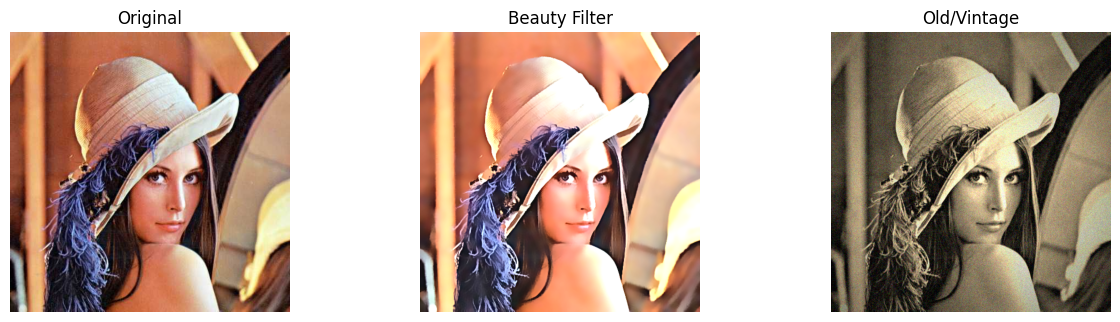

In [9]:
# =====================
# 1. Beauty Filter
# =====================

# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2   # contrast
beta = 15     # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)


# =====================
# 2. Old/Vintage Filter
# =====================

# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

titles = ["Original", "Beauty Filter", "Old/Vintage"]
images = [img, beauty, old_img]

plt.figure(figsize=(15,8))
for i in range(len(images)):
    plt.subplot(2, 3, i+1)
    plt.imshow(cv.cvtColor(images[i], cv.COLOR_BGR2RGB))
    plt.title(titles[i])
    plt.axis('off')

plt.show()

## Percobaan 5 akan menunjukkan pada anda filter anime / cartoon menggunakan kombinasi filter tradisional.

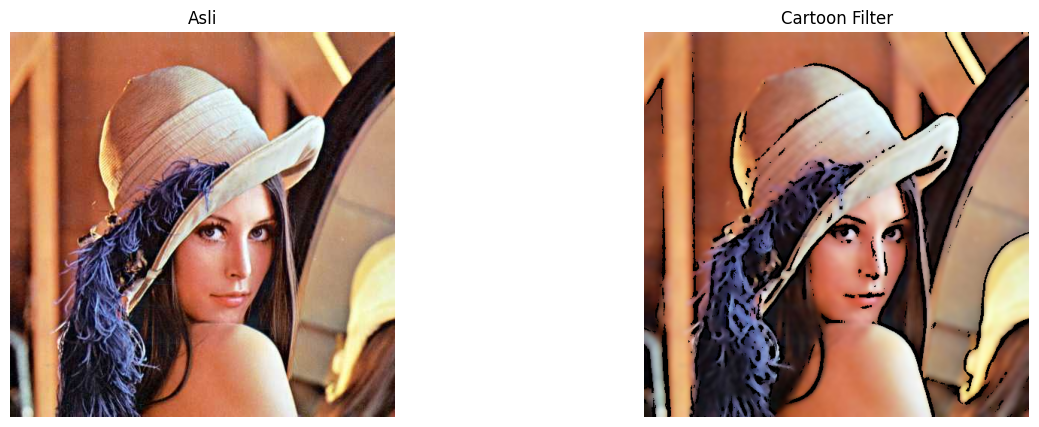

In [11]:
# Filter Anime / Cartoon
# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
import cv2 as cv
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold( gray_blur, 255,
                              cv.ADAPTIVE_THRESH_MEAN_C,
                              cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

## Percobaan 6:

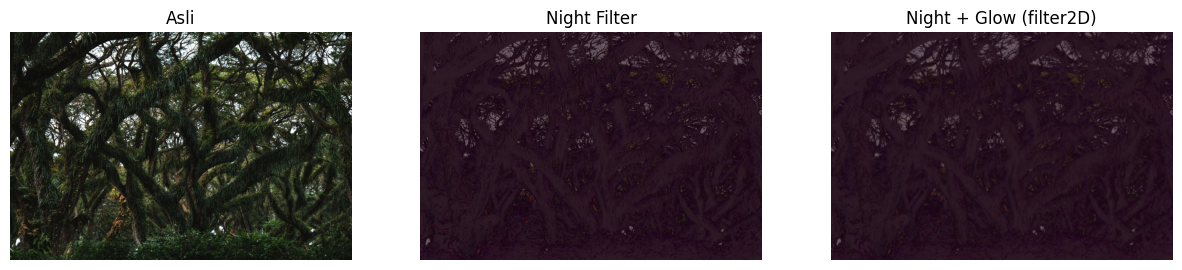

In [13]:
# Night Filter
img = cv.imread("/content/drive/MyDrive/PCVK/Images/djawatan.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15, 15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

# Tampilkan
show_side_by_side(
    [img, night, night_glow],
    ["Asli", "Night Filter", "Night + Glow (filter2D)"])

## Percobaan 7 menunjukkan Filter Pagi dan Pagi ditambahkan efek kabut

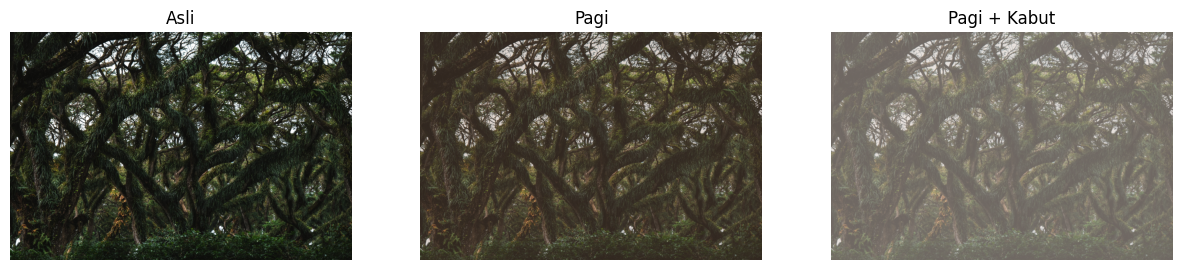

In [14]:
# Filter Suasana pagi dan Kabut
# Step 1: Kurangi kontras & cerahkan
alpha = 0.9   # contrast
beta = 20     # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# Step 2: Tambahkan warm tone (kemerahan / oranye)
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T   # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# Tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

# Tampilkan
show_side_by_side(
    [img, pagi, kabut],
    ["Asli", "Pagi", "Pagi + Kabut"])